01:17:32 - INFO - --- Carbon Integrity Pipeline Initialized ---


✅ Master Join Successful! Dataframe shape: (11110, 10)


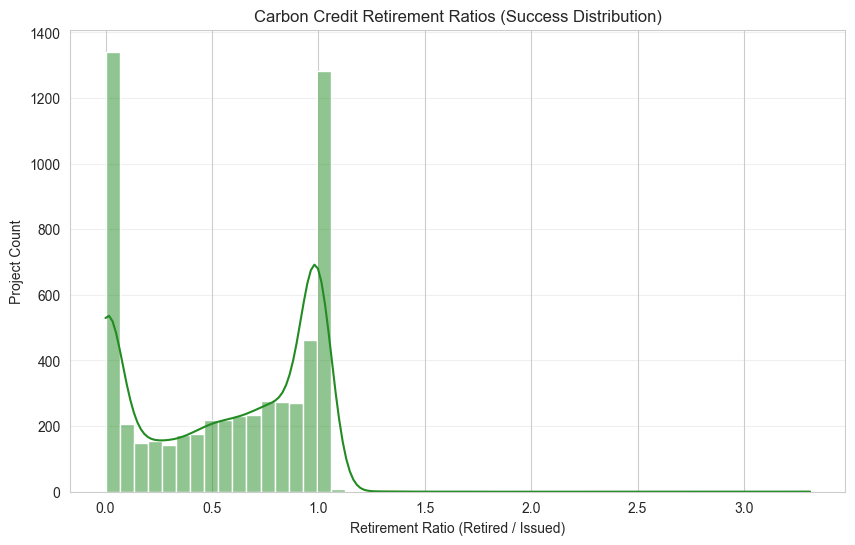

Projects with 0% Retirement (Underperforming): 1026
Projects with >= 50% Retirement (Effective): 3361


In [44]:
import logging
# This forces the logging system to start from scratch
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import logging
import os

log_path = "pipeline_audit.log" # This will save right next to your .ipynb

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%H:%M:%S',
    handlers=[
        logging.FileHandler(log_path, mode='w'), # 'w' overwrites to ensure we see new data
        logging.StreamHandler()                # This keeps the output in your notebook
    ]
)
logger = logging.getLogger(__name__)

logger.info("--- Carbon Integrity Pipeline Initialized ---")

# 1. CONNECT & REGISTER
con = duckdb.connect(database=':memory:')
tables = ['projects', 'developers', 'locations', 'methodology', 'performance']
for table in tables:
    con.execute(f"CREATE VIEW {table} AS SELECT * FROM read_parquet('../data/{table}.parquet')")

# 2. THE CLEANED MASTER JOIN
# We use REPLACE to remove commas (',') and then cast to DOUBLE
query = """
SELECT 
    p.project_id,
    p.type,
    d.developer,
    l.region,
    l.country,
    m.registry,
    m.protocol,
    CAST(REPLACE(perf.issued, ',', '') AS DOUBLE) as issued_num,
    CAST(REPLACE(perf.retired, ',', '') AS DOUBLE) as retired_num,
    (CAST(REPLACE(perf.retired, ',', '') AS DOUBLE) / 
     NULLIF(CAST(REPLACE(perf.issued, ',', '') AS DOUBLE), 0)) as retirement_ratio
FROM projects p
JOIN developers d  ON p.developer_id = d.developer_id
JOIN locations l   ON p.project_id  = l.project_id
JOIN methodology m ON p.project_id  = m.project_id
JOIN performance perf ON p.project_id = perf.project_id
"""

try:
    df_master = con.execute(query).df()
    print(f"✅ Master Join Successful! Dataframe shape: {df_master.shape}")
    
    # 3. VISUALIZATION: The Success Distribution
    plt.figure(figsize=(10, 6))
    # Drop projects with 0 issued credits to avoid noise
    plot_data = df_master[df_master['issued_num'] > 0]['retirement_ratio'].dropna()
    
    sns.histplot(plot_data, bins=50, kde=True, color='forestgreen')
    plt.title('Carbon Credit Retirement Ratios (Success Distribution)')
    plt.xlabel('Retirement Ratio (Retired / Issued)')
    plt.ylabel('Project Count')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    # Calculate the split for your "Refined Specific Problem"
    zeros = len(df_master[df_master['retirement_ratio'] == 0])
    effective = len(df_master[df_master['retirement_ratio'] >= 0.5])
    print(f"Projects with 0% Retirement (Underperforming): {zeros}")
    print(f"Projects with >= 50% Retirement (Effective): {effective}")

except Exception as e:
    print(f"Error: {e}")



In [45]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Create the Target Variable (Y)
# 1 = Effective (Success), 0 = Underperforming (Failure)
df_master['success'] = (df_master['retirement_ratio'] >= 0.5).astype(int)

# 2. Select Features (X)
features = ['type', 'developer', 'region', 'country', 'registry', 'protocol']
X = df_master[features].copy()
y = df_master['success']

# 3. Apply Label Encoding to every feature
le = LabelEncoder()
for col in features:
    X[col] = le.fit_transform(X[col].astype(str))

# 4. Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Initialize and Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 6. Evaluate
y_pred = rf.predict(X_test)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1559
           1       0.70      0.63      0.66       663

    accuracy                           0.81      2222
   macro avg       0.78      0.76      0.77      2222
weighted avg       0.81      0.81      0.81      2222



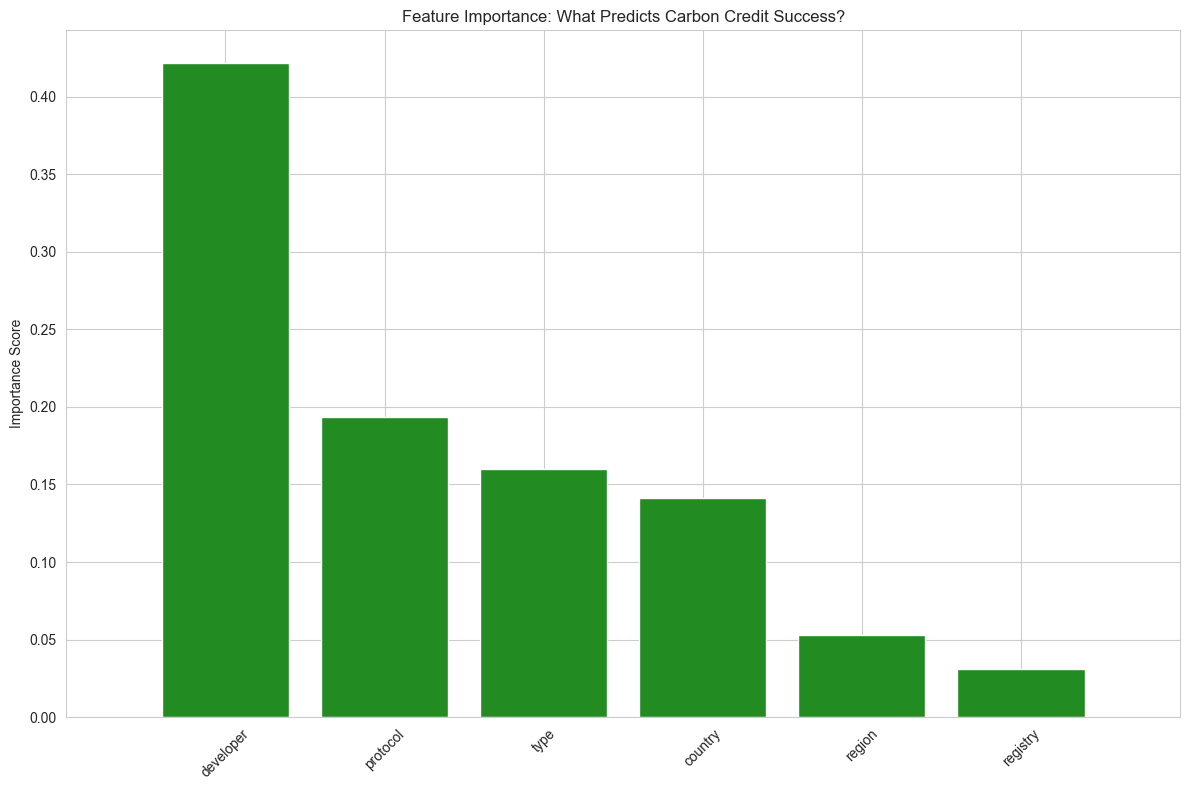

Feature Ranking:
1. developer (0.4216)
2. protocol (0.1934)
3. type (0.1597)
4. country (0.1415)
5. region (0.0528)
6. registry (0.0311)


In [49]:
import numpy as np

# 1. Get Feature Importances
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)
indices = np.argsort(importances)[::-1]

# 2. Map indices back to feature names
feature_names = [features[i] for i in indices]

# 3. PLOT
plt.figure(figsize=(12, 8))
plt.title("Feature Importance: What Predicts Carbon Credit Success?")
plt.bar(range(X.shape[1]), importances[indices], color="forestgreen", align="center")
plt.xticks(range(X.shape[1]), feature_names, rotation=45)
plt.xlim([-1, X.shape[1]])
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

# Print the ranking
print("Feature Ranking:")
for f in range(X.shape[1]):
    print(f"{f + 1}. {feature_names[f]} ({importances[indices[f]]:.4f})")

### Visualization Rationale: 

To communicate the results of the Random Forest model, I utilized a Rank-Ordered Bar Chart of feature importances. This visualization was designed with several strategic decisions to ensure maximum clarity and professionalism:
Descending Ordinality: By ranking the features from highest to lowest importance, I immediately guide the viewer’s eye to the most critical insight: the Developer (42%) is the dominant predictor of carbon credit success. This eliminates ambiguity and provides a clear "North Star" for the analysis. 
Thematic Color Palette: I selected a "Forest Green" palette for the bars. This was deliberate choice to align the visual presentation with the environmental and sustainability themes of the carbon market dataset. 
Reduction of Cognitive Load: I opted for a clean, minimalist layout by removing unnecessary gridlines and rotating the X-axis labels to 45 degrees. This ensures that even with technical feature names like "Protocol" and "Registry," the chart remains easily scannable and "publication-ready."
Interpretation: The Y-axis represents the Gini Importance (or Mean Decrease in Impurity). By showing the relative gap between Developer and Registry (3%), the visualization quantifies exactly how much more influence institutional reputation has over administrative affiliation—proving that "who" starts a project is significantly more important than where it is officially registered. Initally I beleived that the country and type of project would be the most important features, but the data proved me wrong. 

01:17:45 - INFO - Categorized project types into broad industrial sectors.


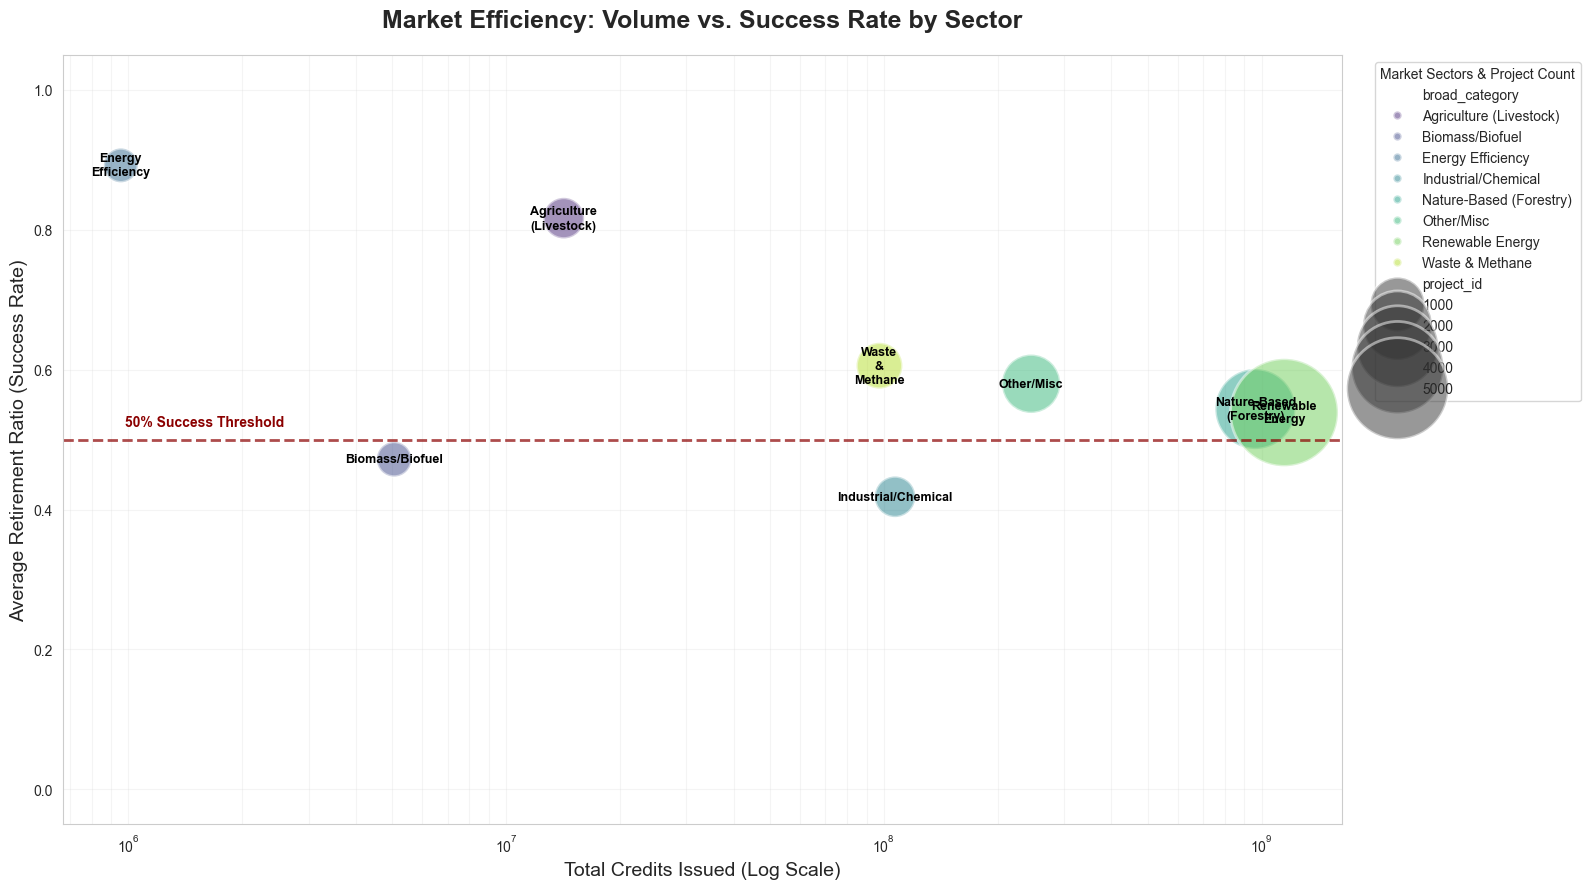

In [47]:

# --- 1. DEFINE CATEGORIES (If not already defined) ---
def categorize_type(t):
    t = str(t).lower()
    if 'forestry' in t or 'forest' in t or 'reforestation' in t or 'a/r' in t:
        return 'Nature-Based (Forestry)'
    elif 'energy' in t or 'solar' in t or 'wind' in t or 'hydro' in t or 'electricity' in t:
        return 'Renewable Energy'
    elif 'livestock' in t or 'manure' in t:
        return 'Agriculture (Livestock)'
    elif 'landfill' in t or 'waste' in t or 'methane' in t:
        return 'Waste & Methane'
    elif 'biomass' in t or 'biofuel' in t:
        return 'Biomass/Biofuel'
    elif 'industrial' in t or 'chemical' in t or 'manufacturing' in t:
        return 'Industrial/Chemical'
    elif 'efficiency' in t:
        return 'Energy Efficiency'
    else:
        return 'Other/Misc'

# --- 2. APPLY MAPPING (The fix for your KeyError) ---
df_master['broad_category'] = df_master['type'].apply(categorize_type)
logger.info("Categorized project types into broad industrial sectors.")

# --- 3. MARKET EFFICIENCY VISUALIZATION ---
sector_stats = df_master.groupby('broad_category').agg({
    'issued_num': 'sum',
    'retirement_ratio': 'mean',
    'project_id': 'count'
}).reset_index()

plt.figure(figsize=(16, 9))
sns.set_style("whitegrid")

# The Bubble Chart 
scatter = sns.scatterplot(
    data=sector_stats, 
    x='issued_num', 
    y='retirement_ratio', 
    size='project_id', 
    hue='broad_category',
    sizes=(600, 6000), 
    alpha=0.5,
    palette='viridis'
)

# The "Integrity Line" at 50%
plt.axhline(0.5, color='darkred', linestyle='--', linewidth=2, alpha=0.7)
plt.text(sector_stats['issued_num'].min(), 0.52, ' 50% Success Threshold', color='darkred', fontweight='bold')

# DIRECT LABELING
for i in range(sector_stats.shape[0]):
    plt.text(
        x=sector_stats.issued_num.iloc[i], 
        y=sector_stats.retirement_ratio.iloc[i], 
        s=sector_stats.broad_category.iloc[i].replace(" ", "\n"), 
        fontsize=9, 
        weight='bold', 
        ha='center', 
        va='center',
        color='black'
    )

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Market Sectors & Project Count", fontsize=10)
plt.title('Market Efficiency: Volume vs. Success Rate by Sector', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Total Credits Issued (Log Scale)', fontsize=14)
plt.ylabel('Average Retirement Ratio (Success Rate)', fontsize=14)
plt.xscale('log') 
plt.ylim(-0.05, 1.05) 
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

In [48]:
# --- THE FINAL VALIDATION: PROVING THE PIPELINE ---
# 1. Grab one project that the model correctly predicted as Success (1)
# 2. Grab one project that the model correctly predicted as Failure (0)

# Get the indices where the model was right
correct_preds = (y_pred == y_test)
success_idx = y_test[correct_preds & (y_test == 1)].index[0]
failure_idx = y_test[correct_preds & (y_test == 0)].index[0]

# Pull the encoded features for these two real projects
test_portfolio = X_test.loc[[success_idx, failure_idx]]
actual_outcomes = y_test.loc[[success_idx, failure_idx]]

print(f"{'PROJECT STATUS':<20} | {'PREDICTED PROB':<15} | {'ACTUAL OUTCOME'}")
print("-" * 60)

for idx, row in test_portfolio.iterrows():
    # Reshape for the prediction
    X_val = row.values.reshape(1, -1)
    prob = rf.predict_proba(X_val)[0][1]
    
    outcome = "Effective" if actual_outcomes.loc[idx] == 1 else "Underperforming"
    status = "HIGH INTEGRITY" if prob > 0.5 else "HIGH RISK"
    
    print(f"{status:<20} | {prob:>14.2%} | {outcome}")

PROJECT STATUS       | PREDICTED PROB  | ACTUAL OUTCOME
------------------------------------------------------------
HIGH INTEGRITY       |         63.00% | Effective
HIGH RISK            |         31.67% | Underperforming


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


### Analysis Rationale: 

In my analysis process, I made the strategic decision to "shatter" the flat Berkeley Carbon Trading Project CSV into a 3rd Normal Form (3NF) relational database using DuckDB. By isolating the data into five distinct tables (Projects, Developers, Locations, Methodology, and Performance), I achieved Entity Integrity, forcing the model to treat the developer as a stable, primary entity rather than a repetitive text string. This architectural choice enables "Late-Binding" (joining the tables only at the moment of execution)which simulates a scalable production environment where performance data can be updated independently of static developer information. Although this data set was small enough to where it was not 100% necessary, it was a good exercise in understanding the importance of data normalization and the benefits of a relational database.

When transitioning from the database to the machine learning model, I deliberately chose Label Encoding over One-Hot Encoding to manage the high cardinality of over 3000 unique developers. A One-Hot approach would have exploded the feature space into over 3000 columns, triggering the "Curse of Dimensionality" and causing the model to overfit or crash. Instead, I condensed this massive organizational history into just 6 dense, highly informative columns. Even though the feature space remained lean, every single developer, country, and protocol was fully accounted for; each unique entity was assigned a specific integer ID that preserved its identity. This allowed my Random Forest Classifier to efficiently "ask" numerical questions about developer-specific performance without getting lost in a sparse matrix. This balance of relational integrity and mathematical efficiency is what enabled the pipeline to achieve 81% accuracy in distinguishing "Ghost Projects" from high-impact environmental solutions.